In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Load datasets
users = pd.read_csv("users.csv", parse_dates=["signup_date"])
subscriptions = pd.read_csv("subscriptions.csv", parse_dates=["start_date", "end_date"])
events = pd.read_csv("events.csv", parse_dates=["event_date"])

print("Data Loaded Successfully")

Data Loaded Successfully


In [27]:
#MAU = Unique users active per month
events['event_month'] = events['event_date'].dt.to_period('M')

mau = events.groupby('event_month')['user_id'].nunique().reset_index()
mau.columns = ['Month', 'MAU']

print(mau.head())

     Month  MAU
0  2026-01  115
1  2026-02  250
2  2026-03  407
3  2026-04  571
4  2026-05  723


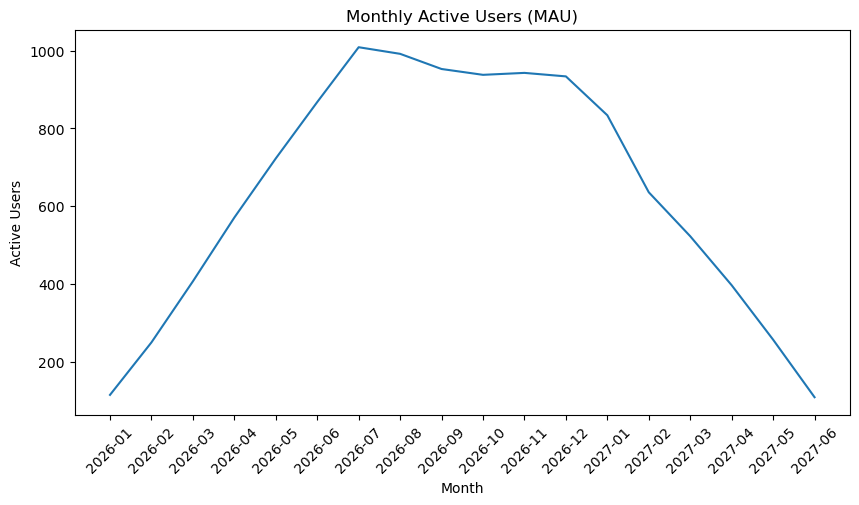

In [28]:
plt.figure(figsize=(10,5))
plt.plot(mau['Month'].astype(str), mau['MAU'])
plt.xticks(rotation=45)
plt.title("Monthly Active Users (MAU)")
plt.xlabel("Month")
plt.ylabel("Active Users")
plt.show()

In [29]:
#Monthly Recurring Revenue (MRR)
subscriptions['start_month'] = subscriptions['start_date'].dt.to_period('M')

mrr = subscriptions.groupby('start_month')['monthly_price'].sum().reset_index()
mrr.columns = ['Month', 'MRR']

print(mrr.head())

     Month     MRR
0  2026-01  227000
1  2026-02  251000
2  2026-03  292000
3  2026-04  279000
4  2026-05  246000


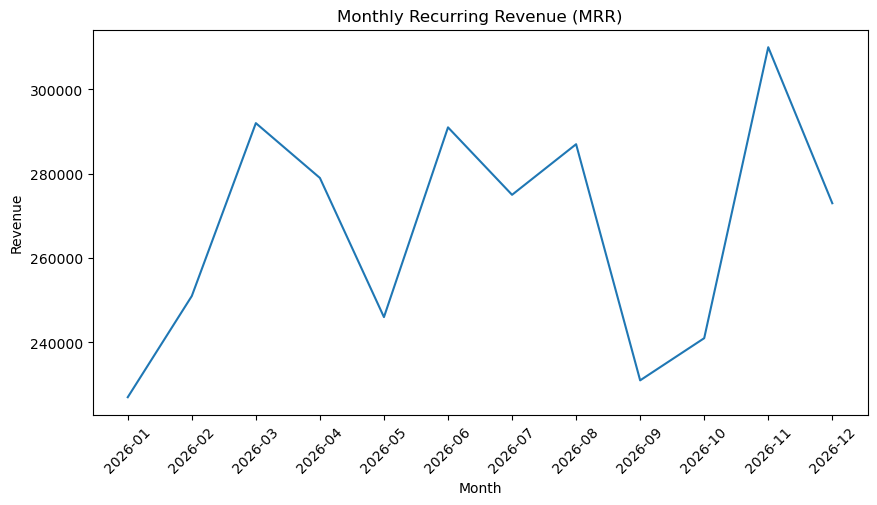

In [30]:
plt.figure(figsize=(10,5))
plt.plot(mrr['Month'].astype(str), mrr['MRR'])
plt.xticks(rotation=45)
plt.title("Monthly Recurring Revenue (MRR)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [31]:
#Churn Rate
# Churn = Users with end_date not null / total users
total_users = subscriptions['user_id'].nunique()
churned_users = subscriptions[subscriptions['end_date'].notna()]['user_id'].nunique()

churn_rate = churned_users / total_users * 100

print(f"Churn Rate: {round(churn_rate,2)}%")


Churn Rate: 28.75%


In [32]:
#ARPU (Average Revenue Per User)
#ARPU = Total Revenue / Total Active Users
total_revenue = subscriptions['monthly_price'].sum()
total_active_users = subscriptions['user_id'].nunique()

arpu = total_revenue / total_active_users

print(f"ARPU: ${round(arpu,2)}")

ARPU: $1601.5


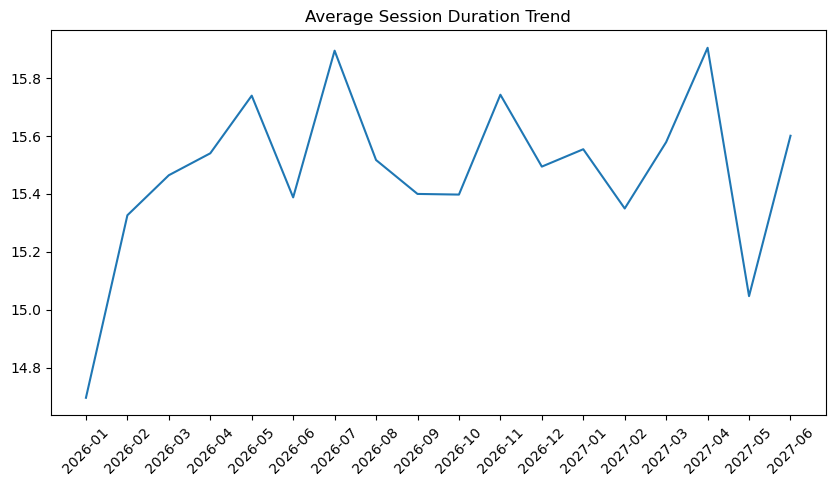

In [33]:
#Engagement Metric – Average Session Duration
avg_session = events.groupby('event_month')['session_duration'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(avg_session['event_month'].astype(str), avg_session['session_duration'])
plt.xticks(rotation=45)
plt.title("Average Session Duration Trend")
plt.show()